In [1]:
import math 
import random 
import numpy as np 
import torch 
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(33)
random.seed(33)
np.random.seed(33)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Pytorch device:", device)

Pytorch device: cpu


## 1. Transformer vocabulary: the shape language

We will use:

- `B` = batch size
- `T` = sequence length / number of tokens
- `D` = model embedding dimension (`d_model`)
- `H` = number of attention heads
- `Dh = D / H` = dimension per head

A tokenized batch normally starts as:

```text
input_ids: [B, T]
```

After embedding:

```text
X: [B, T, D]
```

Attention creates pairwise token scores:

```text
Q @ Kᵀ: [B, H, T, T]
```

and combines those scores with values:

```text
attention_output: [B, T, D]
```

In [2]:
B, T, vocab_size, d_model = 2, 6, 1000, 64

input_ids = torch.randint(0, vocab_size, (B, T), device=device)
embedding = nn.Embedding(vocab_size, d_model).to(device)

x = embedding(input_ids)

print("Input IDs shape:", input_ids.shape)
print("Embedding output shape:", x.shape)

Input IDs shape: torch.Size([2, 6])
Embedding output shape: torch.Size([2, 6, 64])


## 2. Token Embeddings

A Transformer model cannot directly process integer token IDs. Instead, it uses an embedding layer to map each discrete token ID to a continuous, learnable vector:

\[E \in \mathbb{R}^{V \times D}\]

Where:
* $V$ is the **vocabulary size**.
* $D$ is the **embedding dimension**.

For any given token $i$, the model retrieves the corresponding row $E[i]$. In practice, this is implemented as an efficient **index lookup** rather than an explicit one-hot vector multiplication in memory.


In [3]:
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)

    def forward(self, input_ids):
        return self.embedding(input_ids)

tok_emb = TokenEmbedding(vocab_size=1000, d_model=64)
x = tok_emb(input_ids)

print(x.shape)

torch.Size([2, 6, 64])


## 3. Why positional information is necessary

Self-attention by itself does not inherently encode token order.

These sequences contain the same token set:

```text
"dog bites man"
"man bites dog"
```

but their meaning is different.

A Transformer therefore adds positional information to token representations.

We will implement both:

1. **Sinusoidal positional encoding** — fixed, from the original Transformer.
2. **Learned positional embeddings** — common in modern architectures.

In [4]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, max_seq_len, d_model):
        super().__init__()

        position = torch.arange(max_seq_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_seq_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

pe = SinusoidalPositionalEncoding(max_seq_len=128, d_model=64)
x_pos = pe(x)

print("Positional Encoding output shape:", x_pos.shape)

Positional Encoding output shape: torch.Size([2, 6, 64])


In [5]:
class LearnedPositionalEmbedding(nn.Module):
    def __init__(self, max_seq_len, d_model):
        super().__init__()
        self.position_embedding = nn.Embedding(max_seq_len, d_model)

    def forward(self, x):
        B, T, D = x.shape
        positions = torch.arange(T, device=x.device)
        return x + self.position_embedding(positions)[None, :, :]

learned_pe = LearnedPositionalEmbedding(max_seq_len=128, d_model=64)
x_learned_pos = learned_pe(x)

print("Learned Positional Embedding output shape:", x_learned_pos.shape)

Learned Positional Embedding output shape: torch.Size([2, 6, 64])


## 4. Query, Key, Value — the central idea

For each token representation `X`, we create:

\[
Q = XW_Q,\quad K = XW_K,\quad V = XW_V
\]

Interpretation:

- **Query:** what am I looking for?
- **Key:** what kind of information do I contain?
- **Value:** what information should I provide?

Attention first compares queries with keys, then uses the resulting weights to mix values.

In [6]:
D = 8

W_Q = nn.Linear(D, D, bias=False)
W_K = nn.Linear(D, D, bias=False)
W_V = nn.Linear(D, D, bias=False)

toy_x = torch.randn(1, 4, D)

Q = W_Q(toy_x)
K = W_K(toy_x)
V = W_V(toy_x)

print("Q:", Q.shape)
print("K:", K.shape)
print("V:", V.shape)

Q: torch.Size([1, 4, 8])
K: torch.Size([1, 4, 8])
V: torch.Size([1, 4, 8])


## 5. Scaled Dot-Product Attention

The original Transformer defines:

\[
Attention(Q,K,V)
=
softmax\left(

rac{QK^T}{\sqrt{d_k}}

ight)V
\]

### Step-by-step

1. `Q @ Kᵀ` measures query-key compatibility.
2. Divide by `sqrt(d_k)` to control score magnitude.
3. Add a mask if required.
4. Apply softmax to get attention weights.
5. Multiply the weights by `V`.

The output is a weighted mixture of value vectors.

In [7]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)

    scores = Q @ K.transpose(-2, -1)
    scores = scores / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(~mask, float('-inf'))

    weights = F.softmax(scores, dim=-1)
    output = weights @ V

    return output, weights

Q = torch.randn(1, 4, 8)
K = torch.randn(1, 4, 8)
V = torch.randn(1, 4, 8)

out, weights = scaled_dot_product_attention(Q, K, V)

print("scores/weights:", weights.shape)
print("output:", out.shape)
print("row sums:", weights.sum(dim=-1))


scores/weights: torch.Size([1, 4, 4])
output: torch.Size([1, 4, 8])
row sums: tensor([[1.0000, 1.0000, 1.0000, 1.0000]])


## 6. Inspecting attention weights

Each row answers:

> **For this query token, how much attention is paid to every key token?**

Every row sums to approximately 1 because of softmax.

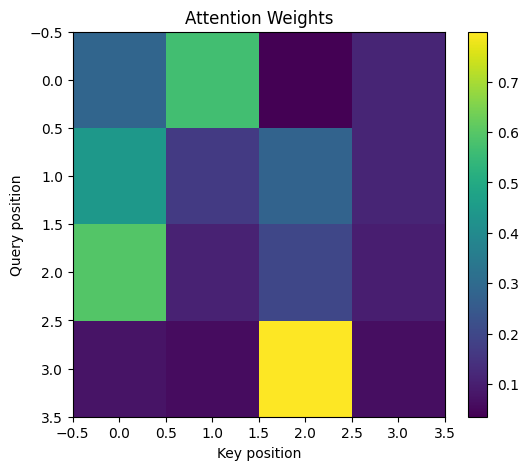

In [8]:
plt.figure(figsize=(6, 5))
plt.imshow(weights[0].detach().cpu(), aspect="auto")
plt.xlabel("Key position")
plt.ylabel("Query position")
plt.title("Attention Weights")
plt.colorbar()
plt.show()

## 7. Padding Mask

Padding is added so sequences of different lengths can share a batch.

Example:

```text
I love AI <PAD> <PAD>
```

The model should not use `<PAD>` as meaningful content.

A boolean attention mask convention used in this notebook is:

- `True`  → allowed
- `False` → blocked

For a key-padding mask, shape is typically `[B, 1, 1, T]`.

In [9]:
def make_padding_mask(input_ids, pad_token_id=0):
    return (input_ids != pad_token_id)[:, None, None, :]


padded_ids = torch.tensor([
    [5, 7, 9, 0, 0],
    [3, 4, 8, 2, 6]
])

padding_mask = make_padding_mask(padded_ids, pad_token_id=0)
print("input:", padded_ids.shape)
print("mask :", padding_mask.shape)
print(padding_mask[0, 0, 0])

input: torch.Size([2, 5])
mask : torch.Size([2, 1, 1, 5])
tensor([ True,  True,  True, False, False])


## 8. Causal / Look-Ahead Mask

Autoregressive language models must not see future tokens.

For sequence length `T`:

```text
✓ ✗ ✗ ✗
✓ ✓ ✗ ✗
✓ ✓ ✓ ✗
✓ ✓ ✓ ✓
```

This is a lower-triangular mask.

It prevents information leakage during next-token prediction.

In [10]:
def make_causal_mask(seq_len, device=None):
    return torch.tril(
        torch.ones(seq_len, seq_len, dtype=torch.bool, device=device)
    )


causal_mask = make_causal_mask(6)
print(causal_mask)

tensor([[ True, False, False, False, False, False],
        [ True,  True, False, False, False, False],
        [ True,  True,  True, False, False, False],
        [ True,  True,  True,  True, False, False],
        [ True,  True,  True,  True,  True, False],
        [ True,  True,  True,  True,  True,  True]])


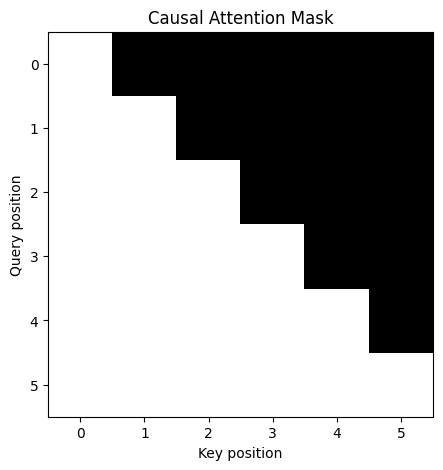

In [11]:
plt.figure(figsize=(5, 5))
plt.imshow(causal_mask.cpu(), cmap="gray")
plt.xlabel("Key position")
plt.ylabel("Query position")
plt.title("Causal Attention Mask")
plt.show()

## 9. Combining causal + padding masks

Real decoder-style attention may need both constraints:

- don't attend to future positions
- don't attend to padding positions

Conceptually, we take the logical AND of the two masks.

In [12]:
def combine_causal_and_padding_masks(input_ids, pad_token_id=0):
    B, T = input_ids.shape

    causal = make_causal_mask(T, input_ids.device)[None, None, :, :]
    padding = make_padding_mask(input_ids, pad_token_id)

    return causal & padding


combined = combine_causal_and_padding_masks(padded_ids)
print(combined.shape) 

torch.Size([2, 1, 5, 5])


## 10. Single-Head Self-Attention

Self-attention means:

\[
Q,K,V
\]

all originate from the **same sequence**.

We'll implement it explicitly instead of calling PyTorch's attention module.

In [13]:
class SelfAttention(nn.Module):
    def __init__(self, d_model, dropout=0.0):
        super().__init__()
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        Q = self.q_proj(x)
        K = self.k_proj(x)
        V = self.v_proj(x)

        out, weights = scaled_dot_product_attention(Q, K, V, mask)
        out = self.out_proj(out)
        out = self.dropout(out)

        return out, weights


single_attn = SelfAttention(64)
out, attn = single_attn(x)

print("input :", x.shape)
print("output:", out.shape)
print("attn  :", attn.shape)    

input : torch.Size([2, 6, 64])
output: torch.Size([2, 6, 64])
attn  : torch.Size([2, 6, 6])


## 11. Multi-Head Attention

Instead of one large attention operation, split the model dimension into `H` heads.

If:

\[
D=64,\quad H=8
\]

then:

\[
D_h = D/H = 8
\]

Shapes become:

```text
X           [B, T, D]
Q,K,V       [B, H, T, Dh]
scores      [B, H, T, T]
output      [B, H, T, Dh]
merge       [B, T, D]
```

Multiple heads let the model learn different attention patterns in parallel.

In [14]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.0):
        super().__init__()

        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        B, T, D = x.shape
        x = x.view(B, T, self.num_heads, self.head_dim)
        return x.transpose(1, 2)  # [B, H, T, Dh]

    def merge_heads(self, x):
        B, H, T, Dh = x.shape
        x = x.transpose(1, 2).contiguous()
        return x.view(B, T, H * Dh)

    def forward(self, x, mask=None, return_weights=False):
        Q = self.split_heads(self.q_proj(x))
        K = self.split_heads(self.k_proj(x))
        V = self.split_heads(self.v_proj(x))

        out, weights = scaled_dot_product_attention(Q, K, V, mask)

        out = self.merge_heads(out)
        out = self.out_proj(out)
        out = self.dropout(out)

        if return_weights:
            return out, weights
        return out


mha = MultiHeadSelfAttention(64, 8)
mha_out, mha_weights = mha(x, return_weights=True)

print("output :", mha_out.shape)
print("weights:", mha_weights.shape)

output : torch.Size([2, 6, 64])
weights: torch.Size([2, 8, 6, 6])


## 12. Residual Connections

A Transformer block does not simply replace its input.

It uses a residual path:

\[
x + Sublayer(x)
\]

This helps optimization and preserves information across layers.

Conceptually:

```text
x ───────────────────────┐
                         +
x → Attention → Norm ────┘
```

In [15]:
x_demo   = torch.randn(2, 6, 64)
sublayer = nn.Linear(64, 64)

residual_out = x_demo + sublayer(x_demo)

print(residual_out.shape)

torch.Size([2, 6, 64])


## 13. Layer Normalization

LayerNorm normalizes features within each token representation.

For a vector `x`:

\[
\hat{x} = 
rac{x-\mu}{\sqrt{\sigma^2+\epsilon}}
\]

followed by learnable scale and shift.

LayerNorm is a core Transformer component.

In [17]:
layer_norm = nn.LayerNorm(64)

y = layer_norm(x_demo)

print("Mean per token: ", y.mean(dim=-1)[0, :3])
print("Std per token : ", y.std(dim=-1, unbiased=False)[0, :3])


Mean per token:  tensor([ 3.1665e-08,  1.6764e-08, -2.6077e-08], grad_fn=<SliceBackward0>)
Std per token :  tensor([1.0000, 1.0000, 1.0000], grad_fn=<SliceBackward0>)


## 14. RMSNorm

Modern LLMs often use RMSNorm.

Unlike LayerNorm, RMSNorm does not subtract the mean.

A simplified form is:

\[
RMS(x)=\sqrt{
rac{1}{D}\sum_i x_i^2+\epsilon}
\]

\[
y = 
rac{x}{RMS(x)}\odot g
\]

In [18]:
class RMSNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(d_model))
        self.eps = eps

    def forward(self, x):
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        return (x / rms) * self.weight


rms = RMSNorm(64)
print(rms(x_demo).shape)

torch.Size([2, 6, 64])


## 15. Feed-Forward Network (FFN)

After attention, every token independently passes through a feed-forward network:

\[
FFN(x)=W_2\,\sigma(W_1x+b_1)+b_2
\]

The same FFN parameters are applied independently to every sequence position.

A common pattern is:

```text
D → 4D → D
```

In [19]:
class FeedForward(nn.Module):
    def __init__(self, d_model, hidden_dim=None, dropout=0.0):
        super().__init__()

        hidden_dim = hidden_dim or 4 * d_model

        self.net = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


ffn = FeedForward(64)
print(ffn(x_demo).shape)

torch.Size([2, 6, 64])


## 16. GELU

GELU is widely used in Transformer FFNs.

Instead of a hard ReLU cutoff, GELU smoothly gates values.

PyTorch provides:

```python
nn.GELU()
```

The important learning point is that the activation is applied **position-wise** after attention.

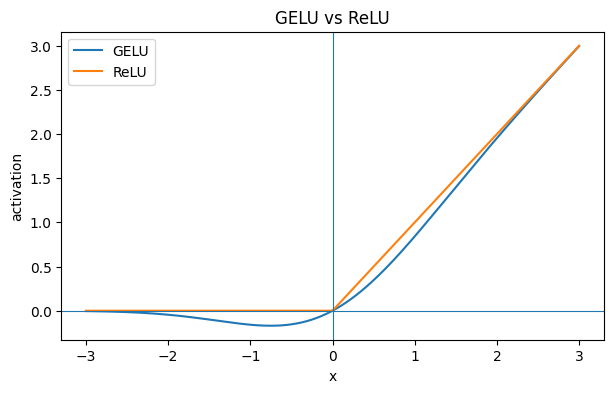

In [20]:
vals = torch.linspace(-3, 3, 200)
gelu_vals = F.gelu(vals)
relu_vals = F.relu(vals)

plt.figure(figsize=(7, 4))
plt.plot(vals, gelu_vals, label="GELU")
plt.plot(vals, relu_vals, label="ReLU")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.legend()
plt.title("GELU vs ReLU")
plt.xlabel("x")
plt.ylabel("activation")
plt.show()

## 17. SwiGLU

SwiGLU is a gated feed-forward design used by several modern language models.

A simplified form is:

\[
SwiGLU(x)=
(W_{up}x)\odot SiLU(W_{gate}x)
\]

followed by a down projection.

It is not part of the original 2017 Transformer, but it is important for modern LLM literature.

In [21]:
class SwiGLU(nn.Module):
    def __init__(self, d_model, hidden_dim=None, dropout=0.0):
        super().__init__()
        hidden_dim = hidden_dim or int(8 * d_model / 3)

        self.up = nn.Linear(d_model, hidden_dim, bias=False)
        self.gate = nn.Linear(d_model, hidden_dim, bias=False)
        self.down = nn.Linear(hidden_dim, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        gated = self.up(x) * F.silu(self.gate(x))
        return self.dropout(self.down(gated))


swiglu = SwiGLU(64)
print(swiglu(x_demo).shape)

torch.Size([2, 6, 64])


# 18. Transformer Encoder Block

A classic Transformer encoder layer contains:

1. Multi-head self-attention
2. Residual connection + normalization
3. Feed-forward network
4. Residual connection + normalization

We will use **Pre-Norm** here because it is common in modern deep Transformers and tends to be easier to train.

The original Transformer used a **Post-Norm** formulation, which we compare later.

In [22]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, ff_hidden_dim=None, dropout=0.0):
        super().__init__()

        self.norm1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, num_heads, dropout)

        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, ff_hidden_dim, dropout)

    def forward(self, x, mask=None):
        x = x + self.attn(self.norm1(x), mask=mask)
        x = x + self.ffn(self.norm2(x))
        return x


encoder_block = TransformerEncoderBlock(64, 8)
encoder_out = encoder_block(x)

print(encoder_out.shape)

torch.Size([2, 6, 64])


## 19. Pre-Norm vs Post-Norm

### Pre-Norm

```text
x → Norm → Attention → +x
x → Norm → FFN       → +x
```

### Post-Norm (original Transformer style)

```text
x → Attention → +x → Norm
x → FFN       → +x → Norm
```

This is an important literature distinction.

Do not conclude that one is universally "correct." They are different architectural choices with different training behavior.

In [23]:
class PostNormEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, ff_hidden_dim=None, dropout=0.0):
        super().__init__()
        self.attn = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.norm1 = nn.LayerNorm(d_model)

        self.ffn = FeedForward(d_model, ff_hidden_dim, dropout)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        attn_out = self.attn(x, mask=mask)
        x = self.norm1(x + attn_out)

        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)

        return x


post_block = PostNormEncoderBlock(64, 8)
print(post_block(x).shape)

torch.Size([2, 6, 64])


# 20. Cross-Attention

Cross-attention is different from self-attention.

Here:

- Query comes from the current decoder representation.
- Key and Value come from encoder outputs.

\[
Q=X_{decoder}W_Q
\]

\[
K=X_{encoder}W_K
\]

\[
V=X_{encoder}W_V
\]

This lets the decoder retrieve information from the source sequence.

In [24]:
class MultiHeadCrossAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.0):
        super().__init__()
        assert d_model % num_heads == 0

        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        B, T, D = x.shape
        return x.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

    def merge_heads(self, x):
        B, H, T, Dh = x.shape
        return x.transpose(1, 2).contiguous().view(B, T, H * Dh)

    def forward(self, query_states, context_states, mask=None, return_weights=False):
        Q = self.split_heads(self.q_proj(query_states))
        K = self.split_heads(self.k_proj(context_states))
        V = self.split_heads(self.v_proj(context_states))

        out, weights = scaled_dot_product_attention(Q, K, V, mask)

        out = self.out_proj(self.merge_heads(out))
        out = self.dropout(out)

        if return_weights:
            return out, weights
        return out


decoder_x = torch.randn(2, 5, 64)
encoder_x = torch.randn(2, 7, 64)

cross = MultiHeadCrossAttention(64, 8)
cross_out, cross_weights = cross(decoder_x, encoder_x, return_weights=True)

print("decoder queries:", decoder_x.shape)
print("encoder context:", encoder_x.shape)
print("cross output   :", cross_out.shape)
print("cross weights  :", cross_weights.shape)

decoder queries: torch.Size([2, 5, 64])
encoder context: torch.Size([2, 7, 64])
cross output   : torch.Size([2, 5, 64])
cross weights  : torch.Size([2, 8, 5, 7])


# 21. Full Encoder–Decoder Transformer

The original Transformer architecture has:

### Encoder
```text
Input
 ↓
Embedding + Position
 ↓
Self-Attention
 ↓
FFN
 ↓
...
 ↓
Encoder representation
```

### Decoder
```text
Previous target tokens
 ↓
Masked Self-Attention
 ↓
Cross-Attention ← Encoder representation
 ↓
FFN
 ↓
...
 ↓
Vocabulary logits
```

This architecture was introduced in **Attention Is All You Need (2017)**.

In [25]:
class TransformerDecoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, ff_hidden_dim=None, dropout=0.0):
        super().__init__()

        self.norm1 = nn.LayerNorm(d_model)
        self.self_attn = MultiHeadSelfAttention(d_model, num_heads, dropout)

        self.norm2 = nn.LayerNorm(d_model)
        self.cross_attn = MultiHeadCrossAttention(d_model, num_heads, dropout)

        self.norm3 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, ff_hidden_dim, dropout)

    def forward(self, x, encoder_states, self_mask=None, cross_mask=None):
        x = x + self.self_attn(self.norm1(x), mask=self_mask)
        x = x + self.cross_attn(
            self.norm2(x),
            encoder_states,
            mask=cross_mask
        )
        x = x + self.ffn(self.norm3(x))
        return x


dec_block = TransformerDecoderBlock(64, 8)
decoder_out = dec_block(
    decoder_x,
    encoder_x,
    self_mask=make_causal_mask(decoder_x.size(1))[None, None, :, :]
)

print(decoder_out.shape)

torch.Size([2, 5, 64])


# 22. GPT-style causal Transformer

GPT-style language models remove the encoder-decoder setup.

They use a stack of **causal decoder-like blocks**, but there is no encoder and therefore no cross-attention.

Core flow:

```text
Token IDs
   ↓
Token Embeddings + Position
   ↓
Causal Self-Attention
   ↓
FFN
   ↓
Repeat N times
   ↓
Final Norm
   ↓
Vocabulary Projection
   ↓
Next-token logits
```

In [28]:
class GPTBlock(nn.Module):
    def __init__(self, d_model, num_heads, ff_hidden_dim=None, dropout=0.0):
        super().__init__()

        self.norm1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, num_heads, dropout)

        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, ff_hidden_dim, dropout)

    def forward(self, x, causal_mask):
        x = x + self.attn(self.norm1(x), mask=causal_mask)
        x = x + self.ffn(self.norm2(x))
        return x


class TinyGPT(nn.Module):
    def __init__(
        self,
        vocab_size,
        max_seq_len,
        d_model=128,
        num_heads=4,
        num_layers=4,
        ff_hidden_dim=None,
        dropout=0.0
    ):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(max_seq_len, d_model)

        self.blocks = nn.ModuleList([
            GPTBlock(d_model, num_heads, ff_hidden_dim, dropout)
            for _ in range(num_layers)
        ])

        self.norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

        # Weight tying is common in language models.
        self.lm_head.weight = self.token_embedding.weight

    def forward(self, input_ids, return_last_attention=False):
        B, T = input_ids.shape

        positions = torch.arange(T, device=input_ids.device)

        x = (
            self.token_embedding(input_ids)
            + self.position_embedding(positions)[None, :, :]
        )

        mask = make_causal_mask(T, input_ids.device)[None, None, :, :]

        for block in self.blocks:
            x = block(x, mask)

        x = self.norm(x)
        logits = self.lm_head(x)

        return logits


model = TinyGPT(
    vocab_size=5000,
    max_seq_len=128,
    d_model=128,
    num_heads=4,
    num_layers=4
).to(device)

sample_ids = torch.randint(0, 5000, (2, 12), device=device)
logits = model(sample_ids)

print("Input :", sample_ids.shape)
print("Logits:", logits.shape)

Input : torch.Size([2, 12])
Logits: torch.Size([2, 12, 5000])


## 23. Next-token prediction

For causal language modeling, we shift the sequence:

```text
Input :  I   love   machine
Target:  love machine learning
```

At every position, the model predicts the token immediately after the current context.

If logits have shape:

```text
[B, T, V]
```

then cross-entropy compares them against target IDs:

```text
[B, T]
```

In [29]:
vocab_size = 5000
B, T = 4, 16

batch = torch.randint(0, vocab_size, (B, T), device=device)

inputs = batch[:, :-1]
targets = batch[:, 1:]

logits = model(inputs)

loss = F.cross_entropy(
    logits.reshape(-1, vocab_size),
    targets.reshape(-1)
)

print("inputs :", inputs.shape)
print("targets:", targets.shape)
print("logits :", logits.shape)
print("loss   :", loss.item())

inputs : torch.Size([4, 15])
targets: torch.Size([4, 15])
logits : torch.Size([4, 15, 5000])
loss   : 85.44828796386719


# 24. Tiny training loop

The following example trains the architecture on random token sequences.

Because the data is random, **do not expect meaningful language learning**.

The purpose is only to verify that:

- forward propagation works
- gradients flow
- the loss can be computed
- parameters update

In [30]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

model.train()

for step in range(20):
    batch = torch.randint(0, vocab_size, (8, 32), device=device)

    inputs = batch[:, :-1]
    targets = batch[:, 1:]

    logits = model(inputs)

    loss = F.cross_entropy(
        logits.reshape(-1, vocab_size),
        targets.reshape(-1)
    )

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if step % 5 == 0:
        print(f"step={step:02d} loss={loss.item():.4f}")

step=00 loss=86.6105
step=05 loss=76.6426
step=10 loss=57.3925
step=15 loss=44.1562


# 25. Greedy next-token generation

At inference time, we repeatedly:

1. feed the current context
2. take the last-position logits
3. select the highest-probability token
4. append it
5. repeat

This is **greedy decoding**.

In [32]:
@torch.no_grad()
def generate_greedy(model, input_ids, max_new_tokens):
    model.eval()

    for _ in range(max_new_tokens):
        context = input_ids[:, -128:]
        logits = model(context)

        next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        input_ids = torch.cat([input_ids, next_token], dim=1)

    return input_ids


prompt = torch.randint(0, vocab_size, (1, 5), device=device)
generated = generate_greedy(model, prompt, max_new_tokens=10)

print("Generated token IDs:")
print(generated)

Generated token IDs:
tensor([[3688, 3352, 3800, 2495, 4025, 4025, 4154, 4154, 4154, 4154, 4154, 4154,
         4154, 4154, 4154]])


# 26. Attention visualization inside a real GPT block

For interpretability, it is useful to inspect the attention matrix.

The matrix has shape:

```text
[batch, heads, query_position, key_position]
```

For a causal model, the upper-right region should be blocked.

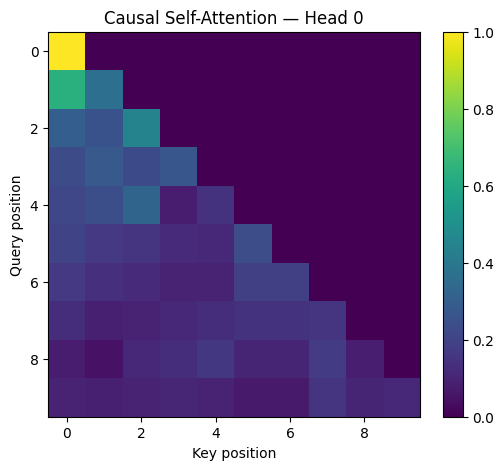

In [33]:
class InspectableGPTBlock(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model)

    def forward(self, x, mask):
        attn_input = self.norm1(x)
        attn_out, weights = self.attn(
            attn_input,
            mask=mask,
            return_weights=True
        )
        x = x + attn_out
        x = x + self.ffn(self.norm2(x))
        return x, weights


inspect_block = InspectableGPTBlock(64, 4).to(device)

ids = torch.randint(0, 100, (1, 10), device=device)
emb = nn.Embedding(100, 64).to(device)(ids)

mask = make_causal_mask(10, device=device)[None, None, :, :]
_, weights = inspect_block(emb, mask)

head0 = weights[0, 0].detach().cpu()

plt.figure(figsize=(6, 5))
plt.imshow(head0, aspect="auto")
plt.xlabel("Key position")
plt.ylabel("Query position")
plt.title("Causal Self-Attention — Head 0")
plt.colorbar()
plt.show()

# 27. Parameter count

A useful Transformer-literature skill is estimating how large an architecture is.

We can count trainable parameters directly.

In [34]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"Trainable parameters: {count_parameters(model):,}")

Trainable parameters: 1,449,728


# 28. Complexity intuition

For standard full self-attention:

\[
QK^T
\]

produces a `T × T` attention matrix.

Therefore, attention computation and memory grow roughly quadratically with sequence length:

\[
O(T^2)
\]

This is one of the major reasons long-context Transformers require efficient-attention techniques.

A useful mental comparison:

```text
T = 1,000  → 1,000,000 pairwise positions
T = 10,000 → 100,000,000 pairwise positions
T = 100,000 → 10,000,000,000 pairwise positions
```

This is why long-context attention is an active research area.

# 29. The complete Transformer mental model

## Encoder-style Transformer

```text
Token IDs
   ↓
Token Embedding
   +
Positional Information
   ↓
┌───────────────────────────────┐
│ Transformer Encoder Block     │
│                               │
│ LayerNorm                     │
│   ↓                           │
│ Multi-Head Self-Attention     │
│   ↓                           │
│ Residual                      │
│   ↓                           │
│ LayerNorm                     │
│   ↓                           │
│ Feed-Forward Network          │
│   ↓                           │
│ Residual                      │
└───────────────────────────────┘
   ↓
Repeat N times
   ↓
Contextual representations
```

## GPT-style Transformer

```text
Token IDs
   ↓
Token Embedding + Position
   ↓
Causal Self-Attention
   ↓
FFN
   ↓
Repeat N times
   ↓
Final Normalization
   ↓
LM Head
   ↓
Next-token probabilities
```

## Original Encoder–Decoder Transformer

```text
SOURCE
  ↓
Encoder
  ↓
Context
  ↓
        Decoder
          ↑
Target → Masked Self-Attention
          ↓
      Cross-Attention ← Context
          ↓
          FFN
          ↓
       Output
```

# 30. What you should be able to explain after this notebook

Before moving deeper into Transformer literature, make sure you can explain these without looking at the code:

### Attention
- Why do we need attention?
- What are Q, K and V?
- Why calculate `QKᵀ`?
- Why divide by `sqrt(d_k)`?
- Why use softmax?
- What does an attention weight represent?

### Masking
- What is a padding mask?
- What is a causal mask?
- Why does GPT need causal masking?
- Why doesn't BERT use causal masking in its normal self-attention?

### Multi-Head Attention
- Why split into multiple heads?
- What is `d_head`?
- What happens after all heads are computed?

### Transformer Block
- Why residual connections?
- Why normalization?
- What does the FFN do?
- Pre-Norm vs Post-Norm?

### Architectures
- Encoder vs decoder
- Self-attention vs cross-attention
- BERT-style vs GPT-style
- Original Transformer vs modern LLM block

### Training
- What is next-token prediction?
- Why are inputs and targets shifted?
- Why is causal masking required during training?